In [92]:
import pandas as pd
import numpy as np


In [93]:
df=pd.read_csv('https://raw.githubusercontent.com/krishnaik06/ANN-CLassification-Churn/refs/heads/main/Churn_Modelling.csv')

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [94]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [95]:
df.shape

(10000, 14)

In [96]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [97]:
df.drop(['RowNumber', 'CustomerId', 'Surname'],axis=1,inplace=True)

df.head(2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


In [98]:
df.duplicated().sum()

np.int64(0)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [100]:
cat_cols=[i for i in df.columns if df[i].dtypes=='O']
num_cols=[i for i in df.columns if df[i].dtypes!='O']

cat_cols,num_cols

(['Geography', 'Gender'],
 ['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary',
  'Exited'])

In [101]:
for i in cat_cols:
    print(i,":",df[i].unique())

    print()

Geography : ['France' 'Spain' 'Germany']

Gender : ['Female' 'Male']



In [102]:
# encoding

# Female->1
# Male->0

df['Gender']=df['Gender'].map({'Female':1,'Male':0})

In [103]:
df.columns=df.columns.str.lower()

In [104]:
cat_cols=[i for i in df.columns if df[i].dtypes=='O']
num_cols=[i for i in df.columns if df[i].dtypes!='O']

cat_cols,num_cols

(['geography'],
 ['creditscore',
  'gender',
  'age',
  'tenure',
  'balance',
  'numofproducts',
  'hascrcard',
  'isactivemember',
  'estimatedsalary',
  'exited'])

In [106]:
num_cols.remove('estimatedsalary')

In [203]:
num_cols.remove('exited')

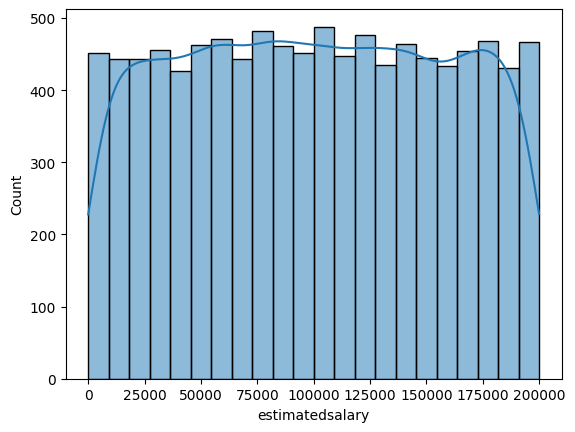

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['estimatedsalary'],kde=True)
plt.show()

In [205]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

scaler=StandardScaler()
ohe=OneHotEncoder(drop='first',handle_unknown='ignore')

preprocessor=ColumnTransformer([
    ("OneHotEncoder",ohe,cat_cols),
    ("StandardScaler",scaler,num_cols)
])

In [206]:
preprocessor

ColumnTransformer(transformers=[('OneHotEncoder',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['geography']),
                                ('StandardScaler', StandardScaler(),
                                 ['creditscore', 'gender', 'age', 'tenure',
                                  'balance', 'numofproducts', 'hascrcard',
                                  'isactivemember'])])

In [207]:
gender_encoding={
    'Female':1,
    'Male':0
}

gender_encoding

{'Female': 1, 'Male': 0}

In [208]:
type(gender_encoding)

dict

In [228]:
X=df.drop(['estimatedsalary','exited'],axis=1)
y=df['estimatedsalary']

In [229]:
X

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember
0,619,France,1,42,2,0.00,1,1,1
1,608,Spain,1,41,1,83807.86,1,0,1
2,502,France,1,42,8,159660.80,3,1,0
3,699,France,1,39,1,0.00,2,0,0
4,850,Spain,1,43,2,125510.82,1,1,1
...,...,...,...,...,...,...,...,...,...
9995,771,France,0,39,5,0.00,2,1,0
9996,516,France,0,35,10,57369.61,1,1,1
9997,709,France,1,36,7,0.00,1,0,1
9998,772,Germany,0,42,3,75075.31,2,1,0


In [230]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [231]:
X_train

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember
9254,686,France,0,32,6,0.00,2,1,1
1561,632,Germany,0,42,4,119624.60,2,1,1
1670,559,Spain,0,24,3,114739.92,1,1,0
6087,561,France,1,27,9,135637.00,1,1,0
6669,517,France,0,56,9,142147.32,1,0,0
...,...,...,...,...,...,...,...,...,...
5734,768,France,0,54,8,69712.74,1,1,1
5191,682,France,1,58,1,0.00,1,1,1
5390,735,France,1,38,1,0.00,3,0,0
860,667,France,0,43,8,190227.46,1,1,0


In [233]:
num_cols.remove('estimatedsalary')

In [234]:
X_train

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember
9254,686,France,0,32,6,0.00,2,1,1
1561,632,Germany,0,42,4,119624.60,2,1,1
1670,559,Spain,0,24,3,114739.92,1,1,0
6087,561,France,1,27,9,135637.00,1,1,0
6669,517,France,0,56,9,142147.32,1,0,0
...,...,...,...,...,...,...,...,...,...
5734,768,France,0,54,8,69712.74,1,1,1
5191,682,France,1,58,1,0.00,1,1,1
5390,735,France,1,38,1,0.00,3,0,0
860,667,France,0,43,8,190227.46,1,1,0


In [235]:
X_train_scaled=preprocessor.fit_transform(X_train)
X_test_scaled=preprocessor.transform(X_test)

In [236]:
X_train.shape

(8000, 9)

In [237]:
X_train_scaled.shape

(8000, 10)

In [238]:
X_train_scaled

array([[ 0.        ,  0.        ,  0.35649971, ...,  0.80843615,
         0.64920267,  0.97481699],
       [ 1.        ,  0.        , -0.20389777, ...,  0.80843615,
         0.64920267,  0.97481699],
       [ 0.        ,  1.        , -0.96147213, ..., -0.91668767,
         0.64920267, -1.02583358],
       ...,
       [ 0.        ,  0.        ,  0.86500853, ...,  2.53355998,
        -1.54035103, -1.02583358],
       [ 0.        ,  0.        ,  0.15932282, ..., -0.91668767,
         0.64920267, -1.02583358],
       [ 1.        ,  0.        ,  0.47065475, ..., -0.91668767,
         0.64920267,  0.97481699]])

In [239]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [240]:
(X_train_scaled.shape[1],)

(10,)

In [241]:
model=Sequential([
    Dense(64,activation='relu',input_shape=(X_train_scaled.shape[1],)),
    Dense(32,activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam',loss='mean_absolute_error',metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [242]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [243]:
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime

log_dir="regressionlogs/fit/"+datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback=TensorBoard(log_dir=log_dir,histogram_freq=1)

es=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

In [244]:

print(y_train.dtypes)

float64


In [245]:
history=model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=200,callbacks=[tensorboard_callback,es])

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 100354.2344 - mae: 100354.2344 - val_loss: 98431.0625 - val_mae: 98431.0625
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 99339.6328 - mae: 99339.6328 - val_loss: 96408.7266 - val_mae: 96408.7266
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 95909.4844 - mae: 95909.4844 - val_loss: 91427.6641 - val_mae: 91427.6641
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 89409.7422 - mae: 89409.7422 - val_loss: 83506.9922 - val_mae: 83506.9922
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 80449.1406 - mae: 80449.1406 - val_loss: 73931.8438 - val_mae: 73931.8438
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 70745.1172 - mae: 70745.1172 - val_loss: 64906.1172 - val_mae: 64906.1172
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 62462.0469 - mae: 62462.0469 - val_loss: 58093.1211 - val_mae: 58093.1211
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step 

In [246]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [247]:
%reload_ext tensorboard

In [248]:
%tensorboard --regressionlogs/

ERROR: Failed to launch TensorBoard (exited with 2).
Contents of stderr:
2026-04-07 18:49:53.583563: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775587793.604197   46324 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775587793.610778   46324 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775587793.627186   46324 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775587793.627208   46324 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:17

In [249]:
# evaluate

test_loss,test_mae=model.evaluate(X_test_scaled,y_test)
print("Test MAE:",test_mae)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 50213.2305 - mae: 50213.2305
Test MAE: 50213.23046875


In [250]:
model

<Sequential name=sequential_4, built=True>

In [251]:
gender_encoding

{'Female': 1, 'Male': 0}

In [252]:
# save model and preprocessor
import json
import joblib

joblib.dump(preprocessor,"models/preprocessor.joblib",compress=3)

with open('models/gender_encoding.json', 'w') as f:
    json.dump(gender_encoding, f)

model.save('models/model.keras')



In [259]:
import pandas as pd

new_data = pd.DataFrame([{
    "creditscore": 790,
    "geography": "France",
    "gender": "Male",
    "age": 20,
    "tenure": 2,
    "balance": 0.00,
    "numofproducts": 1,
    "hascrcard": 1,
    "isactivemember": 1
}])

In [260]:
new_data

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember
0,790,France,Male,20,2,0.0,1,1,1


In [261]:
from tensorflow.keras.models import load_model


with open('models/gender_encoding.json', 'r') as f:
    gender_encoding = json.load(f)

preprocessor = joblib.load("models/preprocessor.joblib")

model = load_model("models/model.keras")

In [262]:
new_data['gender']=new_data['gender'].map(gender_encoding)

In [263]:
new_data

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember
0,790,France,0,20,2,0.0,1,1,1


In [264]:
X_processed = preprocessor.transform(new_data)

prediction = model.predict(X_processed)

print(prediction[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step
[92682.234]
